In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1000

# 1. EQUIPO ALFA: Simétrico (Sigue perfecto)
alfa = np.random.normal(loc=3000, scale=200, size=n)

# 2. EQUIPO BETA: Sesgo a la Derecha (Media >> Mediana)
# Mantuvimos la brecha de ~1600
base_beta = np.random.normal(loc=2500, scale=300, size=900)
outliers_beta = np.random.uniform(low=15000, high=25000, size=100) 
beta = np.concatenate([base_beta, outliers_beta])

# 3. EQUIPO GAMMA: Sesgo a la Izquierda AGRESIVO (Media << Mediana)
# Aumentamos los outliers al 20% y los bajamos a valores casi nulos
# para que la media "se desplome" respecto a la mediana
base_gamma = np.random.normal(loc=6000, scale=300, size=800)
outliers_gamma = np.random.uniform(low=0, high=100, size=200) # 200 personas ganando casi 0
gamma = np.concatenate([base_gamma, outliers_gamma])

# Crear DataFrame y mezclar
df_analisis = pd.DataFrame({
    'Equipo_Alfa': alfa,
    'Equipo_Beta': beta,
    'Equipo_Gamma': gamma
}).sample(frac=1).reset_index(drop=True)

# Guardar CSV final
df_analisis.to_csv('dataset_metricas_equipos.csv', index=False)

# --- VERIFICACIÓN DE LA NUEVA BRECHA ---
resumen = pd.DataFrame({
    'Media': df_analisis.mean(),
    'Mediana': df_analisis.median(),
    'Diferencia (Absoluta)': (df_analisis.mean() - df_analisis.median()).abs()
})
print(resumen.round(2))

                Media  Mediana  Diferencia (Absoluta)
Equipo_Alfa   3003.87  3005.06                   1.19
Equipo_Beta   4310.02  2555.38                1754.64
Equipo_Gamma  4814.98  5911.64                1096.67


In [37]:
numerical_values = df_analisis.columns.to_list()
numerical_values

['Equipo_Alfa', 'Equipo_Beta', 'Equipo_Gamma']

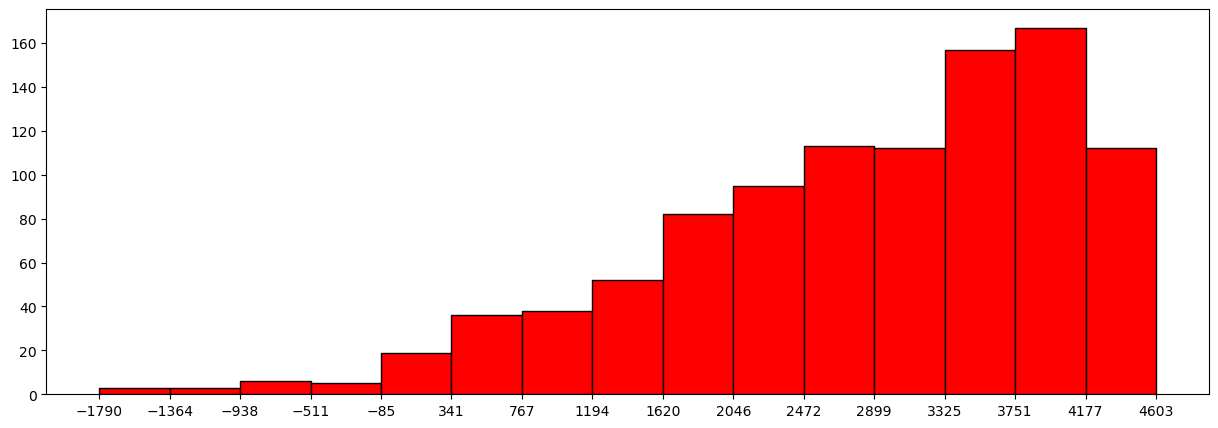

In [38]:
plt.figure(figsize = (15,5))
_,bin_edges,_ = plt.hist(x = df_analisis['Equipo_Gamma'], bins = 15, edgecolor = "black", label = "Total Revenue absolute frequency", color = 'red')
plt.xticks(bin_edges)
plt.show()
